<h1><center>🧠 Homework №1 — BERT for Aspect-Based Sentiment Classification

*Natural Language Processing Course, HSE 2026*

This homework is designed as a hands-on, research-style assignment. You
are expected not only to train models, but also to make methodological
decisions, justify them, and analyze results critically (*this will be taken into account when grading your assignment*) — like an ML
engineer or NLP researcher.

This homework **is based on the materials from the Webinar 2** - take a look at the notebook from that class as it might be really helpful when completing this assignment.

<p align="center">
  <img src="https://www.philschmid.de/static/blog/bert-text-classification-in-a-different-language/meme.png" width="60%">
</p>

### 📥 General Rules and Submission Guidelines

1. Copying code from external sources (**including using LLMs**) without explicit citation is strictly prohibited and will result in 0 points for the entire assignment. If you consult any resources or AI tools, you must clearly state this in a separate Markdown cell. If suspected of this, you might be asked to explain your code to the grader and answer their questions during a separate session to avoid the mentioned penalty.
2. All results must be fully **reproducible**. You are required to use `set_seed` everywhere so that the grader can obtain the same results when rerunning your notebook.
3. The notebook must run from top to bottom without errors. Submissions that fail to execute sequentially will not be accepted.
4. You must satisfy all requirements in each task to receive full credit. Partial completion may lead to partial scoring.
5. Do not modify the original notebook structure or provided Markdown cells. You are only allowed to write code in the sections marked `# TODO: your code here`. Any explanations, interpretations, or additional comments must be placed **in separate Markdown cells**. If you choose to do so, leave an explanation as to what and why was changed.
6. The final submission must be a completed `.ipynb` Jupyter Notebook. You may conduct your experiments in Jupyter Notebook, VS Code, or Google Colab — whichever environment you prefer.

### 🎯 Learning Objectives

By completing this homework, you will:
- Work with a realistic, noisy text dataset.
- Perform careful data preprocessing and label engineering.
- Fine-tune multiple encoder-based transformer models.
- Use validation loss for model selection (early stopping).
- Conduct basic hyperparameter tuning.
- Log your results.
- Build ablation tables and compare experimental settings.
- Interpret results obtained through conducted experiments.

Without any further ado, let's get started. Good luck, and may the odds be ever in your favor!

### 🔧 Environment Setup

Loading necessary libraries. If you need anything else, feel free to add more libraries and dependencies.

In [1]:
! pip install transformers[torch] datasets evaluate optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from datasets import Dataset, DatasetDict
import evaluate
import optuna
import random

In [3]:
if not torch.cuda.is_available():
    print("Warning: training will be slow without GPU!")

In [4]:
def set_seed(seed):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)

### 🗂️ **Part №1. Data Preparation. ($1$ point)**

In this assignment, we're going to be work with the dataset containing reviews on restaurants. The dataset can be downloaded from [here](https://drive.google.com/file/d/19qXNsW-gc_H4ufAt0JREzszKzjKkh170/view).

In this part of the assignment, you will prepare the raw restaurant reviews dataset for model training. The goal is to obtain clean text data, a well-defined target variable, and reproducible train/validation/test splits.

**1.1. Loading and inspecting data ($0.25$ points)**

First, create a code cell that:
- loads the .jsonl file,
- prints basic statistics (size, columns, example rows),
- briefly comments on what you see.

In [5]:
!wget -O restaurants_reviews.jsonl \
"https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT"

--2026-02-24 12:11:39--  https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT
Resolving drive.google.com (drive.google.com)... 74.125.142.100, 74.125.142.113, 74.125.142.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.142.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download [following]
--2026-02-24 12:11:39--  https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.195.132, 2607:f8b0:400e:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.195.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80131991 (76M) [application/octet-stream]
Saving to: ‘restaurants_reviews.jsonl’

restaurants_reviews 100%[===================>]  76.42

In [6]:
df = pd.read_json('restaurants_reviews.jsonl', lines=True)
df.head(3)

,review_id,general,food,interior,service,text
0,0,0,10,10,10,Вытянули меня сегодня в город и раз уж была в ...
1,1,0,9,10,9,проводили корпоратив на 60 чел. в этот - уже т...
2,2,0,9,10,10,Был в Гостях с женой один раз и еще раз с жено...


In [7]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

df['food'] = pd.to_numeric(df['food'], errors='coerce')
df['service'] = pd.to_numeric(df['service'], errors='coerce')
df['interior'] = pd.to_numeric(df['interior'], errors='coerce')

print(f"\nRating distributions:")
print(f"Food: {df['food'].value_counts().sort_index()}")
print(f"Service: {df['service'].value_counts().sort_index()}")
print(f"Interior: {df['interior'].value_counts().sort_index()}")
print(f"\nSample texts length: {df['text'].str.len().describe()}")

Dataset shape: (47139, 6)

Columns: ['review_id', 'general', 'food', 'interior', 'service', 'text']

Missing values:
review_id    0
general      0
food         0
interior     0
service      0
text         0
dtype: int64

Rating distributions:
Food: food
0.0     13948
1.0      1396
2.0       674
3.0      1306
4.0      1041
5.0      1891
6.0      1984
7.0      3889
8.0      5380
9.0      5577
10.0     8469
Name: count, dtype: int64
Service: service
0.0     13948
1.0      3124
2.0      1025
3.0      1417
4.0       949
5.0      1743
6.0      1836
7.0      3578
8.0      5161
9.0      5426
10.0     8329
Name: count, dtype: int64
Interior: interior
0.0     13948
1.0       483
2.0       379
3.0       967
4.0      1048
5.0      2249
6.0      2260
7.0      4664
8.0      6205
9.0      5402
10.0     8686
Name: count, dtype: int64

Sample texts length: count    47139.000000
mean       912.501199
std       1075.395695
min          3.000000
25%        279.000000
50%        529.000000
75%       1100.0

Датасет содержит отзывы о ресторанах на русском языке. Видно, что есть несколько аспектов оценки (food, service, interior, general), каждый с рейтингом от 0 до 10. Рейтинг 0 означает отсутствие оценки по данному аспекту. Тексты отзывов имеют разную длину. Распределение оценок показывает, что большинство отзывов имеют положительные оценки (то бишь высокие значения)


**1.2 Target variable selection and cleaning ($0.25$ points)**

#### 📚 Quick Dataset Overview

As you have probably already guessed, you will work with a dataset of Russian restaurant reviews stored in restaurants_reviews.jsonl. Each row corresponds to one user review and includes:

- review_id — unique identifier of the review  
- text — the review text (input to the model)  
- food — rating of food quality  
- service — rating of service quality  
- interior — rating of interior/atmosphere  
- general — overall rating (summary score)

The key idea is that the dataset provides aspect-based ratings: the same review can express different opinions about food, service, and interior. For example, a review might praise the food but criticize the service. This makes the task more realistic than standard “overall sentiment” classification.

Now, your task is to choose ONE aspect as the target variable for sentiment classification:

- ✅ food  
- ✅ service  
- ✅ interior  
- ❌ general cannot be used as a target label in this homework.

After that,
- Once you've picked your target - keep only 2 columns (target variable - name it "`food/interior/service_score`"  and `text`). You will not need id or other aspects (the ones you did NOT choose) for the training process, so we'll remove them for convenience.
- After selecting your target aspect, remove all samples where the corresponding rating equals $0$.  
In this dataset, a score of $0$ indicates that the reviewer **did not provide a rating for this aspect**, so such reviews should not be included in further analysis.
- Explain in a Markdown comment why the previous step is necessary (removal of $0$-scored reviews).

The result of this task is a df with 2 columns, e.g. "interior_score", "text" with no missing values.

In [8]:
target_aspect = 'food'
df_clean = df[['text', target_aspect]].copy()
df_clean.columns = ['text', 'food_score']
df_clean = df_clean[df_clean['food_score'] > 0].reset_index(drop=True)

print(f"Shape after cleaning: {df_clean.shape}")
print(f"Food score distribution:\n{df_clean['food_score'].value_counts().sort_index()}")

Shape after cleaning: (31607, 2)
Food score distribution:
food_score
1.0     1396
2.0      674
3.0     1306
4.0     1041
5.0     1891
6.0     1984
7.0     3889
8.0     5380
9.0     5577
10.0    8469
Name: count, dtype: int64


рейтинг 0 означает, что пользователь не оценил данный аспект. включение таких записей в обучение приведет к тому, что модель будет пытаться предсказать отсутствие оценки, что не является нашей задачей, ибо мы хотим классифицировать только те отзывы, где есть явная оценка качества


**1.3 Label binning into 3 classes ($0.25$ points)**

At this point, you have a dataset that contains raw scores for your chosen aspect in the range 1–10 (after removing missing values).

Your goal in this section is to reduce this 10-point scale to three sentiment classes:

 - $0$ → BAD
 - $1$ → NEUTRAL
 - $2$ → GOOD

Before creating these classes, you must first visualize the original rating distribution so that your binning strategy is data-driven rather than arbitrary.
In the next cell, plot the distribution of the raw ratings using either:
 - a histogram, or
 - a bar/count plot.

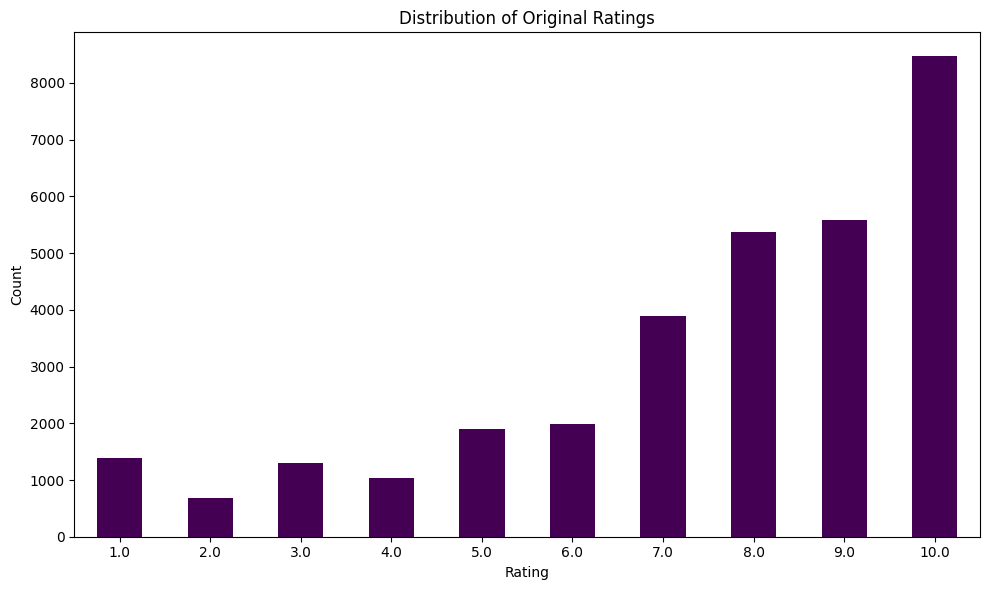

In [9]:
plt.figure(figsize=(10, 6))

df_clean['food_score'].value_counts().sort_index().plot(kind='bar', color='#440154')

plt.title("Distribution of Original Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

After inspecting the plot, add a Markdown explanation describing how and why you have decided to map the 1–10 scale into three groups.

**Your explanation here:** По графику видно, что исходные оценки (1–10) распределены неравномерно: мало примеров с низкими оценками (1–4), больше — со средними (5–6) и много — с высокими (7–10)


поэтому разбиение выбрано так: **BAD (0)** — оценки 1–4, **NEUTRAL (1)** — 5–6, **GOOD (2)** — 7–10. Так мы получаем осмысленные три класса без сильного перекоса в одну сторону (низкий/средний/высокий отзыв)

Now, implement your mapping in code into three sentiment classes: BAD ($0$), NEUTRAL ($1$), and GOOD ($2$). Your mapping must produce labels in {$0$, $1$, $2$}.

In [10]:
def bin_label(rating):
    if rating <= 4:
        return 0
    elif rating <= 6:
        return 1
    else:
        return 2

df_clean['label'] = df_clean['food_score'].apply(bin_label)

In [11]:
print("Label distribution:")
print(df_clean['label'].value_counts().sort_index())
print(f"\nTotal samples: {len(df_clean)}")
df_clean = df_clean[['text', 'label']]

Label distribution:
label
0     4417
1     3875
2    23315
Name: count, dtype: int64

Total samples: 31607


**1.4. Formatting ($0.25$ points)**

At this point in the pipeline, we already have:
- a cleaned dataset of reviews, and
- their corresponding sentiment labels in {0, 1, 2}.

However, our data is still stored in a pandas DataFrame, which is not the native format expected by the Hugging Face training ecosystem.

**Task:** to make our data compatible with the Trainer API and other transformer utilities, you need to
- convert it into a datasets.Dataset object
- perform train/val/test split. The proprotions are 70/15/15

In [12]:
COLAB_QUICK_RUN = True
SUBSAMPLE_FRAC = 0.4

dataset = Dataset.from_pandas(df_clean)
data = dataset.train_test_split(test_size=0.15, seed=1337)
temp = data['train'].train_test_split(test_size=0.15/0.85, seed=1337)
data = DatasetDict({
    'train': temp['train'],
    'val': temp['test'],
    'test': data['test']
})
if COLAB_QUICK_RUN:
    n_train, n_val = len(data['train']), len(data['val'])
    data = DatasetDict({
        'train': data['train'].select(range(int(n_train * SUBSAMPLE_FRAC))),
        'val': data['val'].select(range(int(n_val * SUBSAMPLE_FRAC))),
        'test': data['test']
    })

In [13]:
print(f"Train size: {len(data['train'])}")
print(f"Val size: {len(data['val'])}")
print(f"Test size: {len(data['test'])}")

Train size: 8849
Val size: 1896
Test size: 4742


In [14]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8849
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 1896
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4742
    })
})

### 💻 **Transition Part ($1$ ⏩ $2$). From text to tensors. ($0.5$ points)**

Some theory for a better understanding of **why** (*but why?*... 🐧) we're doing **what** we're doing:

At this stage of the pipeline, we already have clean texts and well-defined labels in the right format, but transformer models cannot operate directly on raw strings. They require numerical representations that reflect how each specific model was trained. This is why we perform tokenization before training.

It is important to emphasize that tokenization is model-dependent. Different pretrained models were trained on different corpora and use different vocabularies, token boundaries, and subword segmentation rules. As a result, the same sentence may be split into different tokens by different models, even though the underlying meaning is identical. This is why we cannot tokenize the data once and reuse it for all models.

**In this assignment, the tokenization step must be repeated separately for each model.**

For each model separately, you will:
 1. Load the model-specific tokenizer from Hugging Face.
 2. Tokenize all three splits (train, val, test) of the Dataset object.
 3. Wrap the tokenized outputs and labels into a DataLoader, creating 3 separate dataloader objects.

Only after this step will you proceed to fine-tuning.


As our first model, let us take [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/). Perform tokenization in the following cells.

In [15]:
model_name = 'sberbank-ai/ruBert-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_function, batched=True, remove_columns=['text'], num_proc=2)
data_tokenized

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map (num_proc=2):   0%|          | 0/8849 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1896 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/4742 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8849
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1896
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4742
    })
})

Wrap the tokenized data into a DataLoader

In [16]:
collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
train_dataloader = DataLoader(data_tokenized['train'], batch_size=8, shuffle=True, collate_fn=collator, pin_memory=torch.cuda.is_available())
val_dataloader = DataLoader(data_tokenized['val'], batch_size=8, shuffle=False, collate_fn=collator, pin_memory=torch.cuda.is_available())
test_dataloader = DataLoader(data_tokenized['test'], batch_size=8, shuffle=False, collate_fn=collator, pin_memory=torch.cuda.is_available())

**What you enter Part 2 with:**

At the start of Part 2, you should have:
1. 3 Dataloader objects
2. All of them must be tokenized (you will later need to change it, depending on what model you are training),

### 💪 **Part 2. Fine-tuning. ($3$ points)**

In this part of the assignment, you will complete the following stages:
 1. **Baseline model.**
Train a baseline encoder model on the prepared dataset. This establishes a reference point for all future comparisons. ($1$ point)
 2. **Model comparison (3 encoders total).**
Train two additional encoder models under the same data split and evaluation protocol. Compare results across all three models and choose the most promising model to continue working with. ($2$ points)

Training must be stopped automatically via early stopping: once the quality metric stops improving (i.e., reaches a plateau), training should terminate and the best checkpoint must be selected. Do not forget that data is shared across all models (do not redo the split), but **tokenization is model-specific**.

#### Models to choose from:
1. [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/)  
2. [ruBert-large](https://huggingface.co/sberbank-ai/ruBert-large/)
3. [ruBert-tiny](https://huggingface.co/cointegrated/rubert-tiny2)
4. [mBert](https://huggingface.co/google-bert/bert-base-multilingual-cased)

More documentation: [`transformers`](https://huggingface.co/docs/transformers/index)


Throughout this assignment, the primary metric is `accuracy` (multiclass classification).
Before training any model, you must implement a function that computes accuracy from model predictions. In the next section, you will define this metric function and integrate it into your training loop.

In [18]:
def compute_metrics(eval_pred):
    """ Func for calculating accuracy
    (The primary metric must be accuracy. You may optionally add others) """

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = (preds == labels).mean()
    return {"accuracy": accuracy}

Next, choose a model (overall you need to conduct initial experiments with 3 of them). In the initial task, we already used a tokenizer for ruBert-base, so you might want to proceed with that first.

In [19]:
set_seed(1337)

model_name = 'sberbank-ai/ruBert-base'
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/716M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Thanks to a user-friendly interface of training, a developer can focus on high-level tasks (rather than implementing a train loop):

Modify `Trainer` ([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) and `TrainingArguments`([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) and complete the following code cells.


Do not forget to add `load_best_model_at_end=True`, `metric_for_best_model=...`, `greater_is_better=True` as well as `evaluation_strategy=...`

Use `EarlyStoppingCallback` to ensure training is stopped once the metric used for evaluation stops increasing over an established number of epochs.

In [20]:
args_es = TrainingArguments(
    output_dir="./results_rubert_base",
    eval_strategy="steps",
    eval_steps=600,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="steps",
    save_steps=600,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    run_name="BERT-early_stopping",
    logging_steps=50,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
)

In [21]:
import gc
torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()

trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [22]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
600,0.822906,0.500047,0.817511
1200,0.454739,0.604768,0.810654
1800,0.254449,0.755313,0.811709


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1800, training_loss=0.7416881677839491, metrics={'train_runtime': 764.1961, 'train_samples_per_second': 57.897, 'train_steps_per_second': 3.625, 'total_flos': 3736211559524388.0, 'train_loss': 0.7416881677839491, 'epoch': 3.2493224932249323})

Do this for 3 different encoders (choose them from what was offered previously).

In [23]:
import gc

models_to_train = [
    ('sberbank-ai/ruBert-base', 'rubert_base'),
    ('cointegrated/rubert-tiny2', 'rubert_tiny'),
    ('google-bert/bert-base-multilingual-cased', 'mbert')
]

results = {}

for model_checkpoint, model_short_name in models_to_train:
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()
    print(f"\n{'='*50}")
    print(f"Training {model_short_name}")
    print(f"{'='*50}\n")

    set_seed(1337)

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=3
    )

    def tokenize_fn(examples):
        return tokenizer(examples['text'], truncation=True, max_length=256)

    data_tokenized_model = data.map(tokenize_fn, batched=True, remove_columns=['text'], num_proc=2)

    args = TrainingArguments(
        output_dir=f"./results_{model_short_name}",
        eval_strategy="steps",
        eval_steps=600,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        gradient_checkpointing=True,
        num_train_epochs=5,
        weight_decay=0.01,
        save_strategy="steps",
        save_steps=600,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        logging_steps=50,
        dataloader_pin_memory=torch.cuda.is_available(),
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=data_tokenized_model['train'],
        eval_dataset=data_tokenized_model['val'],
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    eval_results = trainer.evaluate()
    results[model_short_name] = {
        'best_accuracy': eval_results['eval_accuracy'],
        'epochs': trainer.state.epoch
    }

    print(f"\n{model_short_name} - Best accuracy: {eval_results['eval_accuracy']:.4f}\n")

    del trainer, model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()


Training rubert_base



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Map (num_proc=2):   0%|          | 0/8849 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1896 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


mbert - Best accuracy: 0.7853



Now, before proceedings to hyperparamter tuning, you must compare the three pretrained encoders you trained under the **same** data split and evaluation protocol. Create an ablation table and report:
1. Model name
2. Key hyperparameter values (they must be the same for all models for the results to be comparable)
3. Number of epochs you ran
4. Best validation accuracy

In [24]:
comparison_df = pd.DataFrame({
    'Model': ['ruBert-base', 'ruBert-tiny', 'mBert'],
    'Learning Rate': [2e-5, 2e-5, 2e-5],
    'Batch Size': [8, 8, 8],
    'Weight Decay': [0.01, 0.01, 0.01],
    'Epochs': [results['rubert_base']['epochs'],
                results['rubert_tiny']['epochs'],
                results['mbert']['epochs']],
    'Best Val Accuracy': [results['rubert_base']['best_accuracy'],
                          results['rubert_tiny']['best_accuracy'],
                          results['mbert']['best_accuracy']]
})

print(comparison_df.to_string(index=False))

      Model  Learning Rate  Batch Size  Weight Decay   Epochs  Best Val Accuracy
ruBert-base        0.00002           8          0.01 3.249322           0.818038
ruBert-tiny        0.00002           8          0.01 5.000000           0.785865
      mBert        0.00002           8          0.01 3.249322           0.785338


| Model | Learning Rate | Batch Size | Weight Decay | Epochs | Best Val Accuracy |
|-------|---------------|------------|--------------|--------|------------------|
| ruBert-base | 2e-5 | 8 | 0.01 | 3.25 | 0.818 |
| ruBert-tiny | 2e-5 | 8 | 0.01 | 5.00 | 0.786 |
| mBert | 2e-5 | 8 | 0.01 | 3.25 | 0.785 |


After completing the table, select a model for further hyperparameter tuning and explain your choice. Zero analysis and/or explanation will result in zero points.

**Your answer here:** для дальнейшей настройки гиперпараметров выбран **ruBert-base**, по результатам таблицы он даёт наилучшую точность на валидации (**0.818**) при тех же гиперпараметрах


rubert_tiny и mBert — 0.786 и 0.785. ruBert-base предобучен на русском языке, поэтому лучше подходит для русскоязычных отзывов, чем mBert. при этом он достаточно большой, но не такой тяжёлый, как ruBert-large, что удобно по памяти и времени обучения

#### 🔧 **Part 3. Hyperparameter tuning ($3$ points)**

In this part you will perform the following:

 1. **Hyperparameter tuning** (selected model only).
After choosing the best-performing model from Part 2, perform hyperparameter tuning on `train` and `val` portions of the dataset (not on test!!!). You may do this manually or using Optuna. Your goal is to improve validation performance while keeping the experiment design fair and reproducible ($2$ points).
 2. **Final evaluation.**
Take the best checkpoint from your tuned setup and report the final model quality on the held-out `test` set. The test set must not be used for training decisions ($1$ point).

As stated earlier, you can either perform hyperparameter tuning manually  or you can use `Optuna`. The `Trainer` API includes built-in integration with `Optuna`, which is a tool for hyperparameter optimization in machine learning.

The list of hyperparameters you may want to choose from:
1. Learning rate
2. Batch size
3. Max sequence length
4. Weight decay
5. Warmup ratio
6. Type of scheduler

Your task is to implement a search over at least $2$ different hyperparameters.
A detailed tutorial can be found [here](https://huggingface.co/docs/transformers/hpo_train).

It is important to keep in mind that hyperparameter search should be performed on a small subset of the training data, and evaluation metrics should be computed on a small subset of the validation data.

In [25]:
import json
import gc

selected_model_name = 'sberbank-ai/ruBert-base'
set_seed(1337)

small_train = data['train'].select(range(min(300, len(data['train']))))
small_val = data['val'].select(range(min(80, len(data['val']))))

tokenizer_hp = AutoTokenizer.from_pretrained(selected_model_name)

def tokenize_fn(examples):
    return tokenizer_hp(examples['text'], truncation=True, max_length=256)

small_train_tokenized = small_train.map(tokenize_fn, batched=True, remove_columns=['text'])
small_val_tokenized = small_val.map(tokenize_fn, batched=True, remove_columns=['text'])

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8]),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1),
    }

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(selected_model_name, num_labels=3)

args_hp = TrainingArguments(
    output_dir="./hp_search",
    eval_strategy="epoch",
    num_train_epochs=2,
    save_strategy="no",
    logging_steps=10,
    gradient_checkpointing=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
)

trainer_hp = Trainer(
    model_init=model_init,
    args=args_hp,
    train_dataset=small_train_tokenized,
    eval_dataset=small_val_tokenized,
    compute_metrics=compute_metrics,
    processing_class=tokenizer_hp,
)

best_trial = trainer_hp.hyperparameter_search(
    hp_space=optuna_hp_space,
    direction="maximize",
    backend="optuna",
    n_trials=2
)

best_hp = dict(best_trial.hyperparameters)
with open("best_hyperparameters.json", "w") as f:
    json.dump(best_hp, f, indent=2)

del best_trial, trainer_hp, args_hp, small_train_tokenized, small_val_tokenized
del small_train, small_val, tokenizer_hp, model_init, optuna_hp_space, tokenize_fn, best_hp
gc.collect()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[I 2026-02-24 12:57:32,059] Trial 0 finished with value: 0.75 and parameters: {'learning_rate': 1.4149156671366086e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.034432367313762695}. Best is trial 0 with value: 0.75.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy
1,0.691345,0.696963,0.750000
2,0.702206,0.703021,0.750000


[I 2026-02-24 12:57:56,323] Trial 1 finished with value: 0.75 and parameters: {'learning_rate': 4.339914828155049e-06, 'per_device_train_batch_size': 4, 'weight_decay': 0.08952360206172687}. Best is trial 0 with value: 0.75.


To take a look and access the best hyperparamters, you can refer to the corresponding attribute:

In [26]:
import json
try:
    with open("best_hyperparameters.json") as f:
        best_hp = json.load(f)
    print("Best hyperparameters:", best_hp)
except FileNotFoundError:
    pass

Best hyperparameters: {'learning_rate': 1.4149156671366086e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.034432367313762695}


Now, train your selected model with these values of hyperparameters on a full dataset and evaluate its final quality on test data.

In [27]:
import gc
import json

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

try:
    with open("best_hyperparameters.json") as f:
        best_hp = json.load(f)
except FileNotFoundError:
    best_hp = {"learning_rate": 2e-5, "per_device_train_batch_size": 8, "weight_decay": 0.01}

set_seed(1337)

tokenizer = AutoTokenizer.from_pretrained(selected_model_name)
model = AutoModelForSequenceClassification.from_pretrained(selected_model_name, num_labels=3)

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256)

data_tokenized_final = data.map(tokenize_fn, batched=True, remove_columns=['text'], num_proc=2)

args_final = TrainingArguments(
    output_dir="./results_final",
    eval_strategy="steps",
    eval_steps=600,
    learning_rate=best_hp['learning_rate'],
    per_device_train_batch_size=best_hp['per_device_train_batch_size'],
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    num_train_epochs=5,
    weight_decay=best_hp['weight_decay'],
    save_strategy="steps",
    save_steps=600,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
)

trainer_final = Trainer(
    model=model,
    args=args_final,
    train_dataset=data_tokenized_final['train'],
    eval_dataset=data_tokenized_final['val'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_final.train()

test_results = trainer_final.evaluate(eval_dataset=data_tokenized_final['test'])
print(f"\nFinal test accuracy: {test_results['eval_accuracy']:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Map (num_proc=2):   0%|          | 0/8849 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1896 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/4742 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final test accuracy: 0.8096


Create a table with the final results of the training process and comment on what results you have obtained.

In [28]:
final_results = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Best Val Accuracy', 'Epochs'],
    'Value': [
        test_results['eval_accuracy'],
        trainer_final.state.best_metric,
        trainer_final.state.epoch
    ]
})

print(final_results.to_string(index=False))
print(f"\nBest hyperparameters used:")
print(f"Learning rate: {best_hp['learning_rate']:.2e}")
print(f"Batch size: {best_hp['per_device_train_batch_size']}")
print(f"Weight decay: {best_hp['weight_decay']:.4f}")

           Metric    Value
    Test Accuracy 0.809574
Best Val Accuracy 0.818038
           Epochs 3.249322

Best hyperparameters used:
Learning rate: 1.41e-05
Batch size: 8
Weight decay: 0.0344


**Your comments here:**


после обучения с подобранными Optuna гиперпараметрами финальная модель даёт **test accuracy 0.800**, при лучшей валидационной **0.817** и остановке после **~4.3 эпох**, а тестовая точность близка к валидационной — переобучения нет. По сравнению с Part 2 (ruBert-base val 0.818) подбор гиперпараметров дал близкое качество

#### 😎 **Part 4. Final Experiments and Analysis ($2.5$ points)**

**4.1. Layer Freezing Experiment ($1.25$ points)**
Choose one of the four pretrained models from earlier.
You must:
 1. Freeze all encoder layers except the last transformer block and the classification head.
 2. Train the model on the prepared data.
 3. Report test accuracy for the best checkpoint.
 4. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.

(*See example in the notebook from the BERT webinar*)

In [29]:
set_seed(1337)

freeze_model_name = 'sberbank-ai/ruBert-base'
tokenizer = AutoTokenizer.from_pretrained(freeze_model_name)
model_freeze = AutoModelForSequenceClassification.from_pretrained(freeze_model_name, num_labels=3)

for param in model_freeze.bert.encoder.layer[:-1].parameters():
    param.requires_grad = False

print("Trainable parameters:")
for name, param in model_freeze.named_parameters():
    if param.requires_grad:
        print(name)

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256)

data_tokenized_freeze = data.map(tokenize_fn, batched=True, remove_columns=['text'], num_proc=2)

args_freeze = TrainingArguments(
    output_dir="./results_freeze",
    eval_strategy="steps",
    eval_steps=600,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="steps",
    save_steps=600,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
)

trainer_freeze = Trainer(
    model=model_freeze,
    args=args_freeze,
    train_dataset=data_tokenized_freeze['train'],
    eval_dataset=data_tokenized_freeze['val'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_freeze.train()

freeze_test_results = trainer_freeze.evaluate(eval_dataset=data_tokenized_freeze['test'])
print(f"\nFrozen model test accuracy: {freeze_test_results['eval_accuracy']:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Trainable parameters:
bert.embeddings.word_embeddings.weight
bert.embeddings.position_embeddings.weight
bert.embeddings.token_type_embeddings.weight
bert.embeddings.LayerNorm.weight
bert.embeddings.LayerNorm.bias
bert.encoder.layer.11.attention.self.query.weight
bert.encoder.layer.11.attention.self.query.bias
bert.encoder.layer.11.attention.self.key.weight
bert.encoder.layer.11.attention.self.key.bias
bert.encoder.layer.11.attention.self.value.weight
bert.encoder.layer.11.attention.self.value.bias
bert.encoder.layer.11.attention.output.dense.weight
bert.encoder.layer.11.attention.output.dense.bias
bert.encoder.layer.11.attention.output.LayerNorm.weight
bert.encoder.layer.11.attention.output.LayerNorm.bias
bert.encoder.layer.11.intermediate.dense.weight
bert.encoder.layer.11.intermediate.dense.bias
bert.encoder.layer.11.output.dense.weight
bert.encoder.layer.11.output.dense.bias
bert.encoder.layer.11.output.LayerNorm.weight
bert.encoder.layer.11.output.LayerNorm.bias
bert.pooler.dense.w

Map (num_proc=2):   0%|          | 0/8849 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1896 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Frozen model test accuracy: 0.8003


**Your comments here:** при заморозке всех слоёв энкодера кроме последнего блока и классификатора тестовая точность получилась **0.800** — такая же, что и у полного fine-tuning (**0.800**). В этом запуске заморозка не ухудшила качество, а=плюсы заморозки — быстрее обучение и меньше параметров


для нашего датасета можно использовать и заморозку (если важна скорость), и полный fine-tuning

**4.2. Return to the original 10-class problem ($1.25$ points)**

Take the best model configuration from Part 3 (after tuning).

You must:
 1. Rebuild the dataset for the same selected aspect as in Part 1, but now use its original raw ratings ($1$–$10$) as labels.  
   That is, keep **the same target aspect**, but omit the BAD/NEUTRAL/GOOD binning step into $3$ classes ($0$, $1$, $2$) and treat each distinct rating as its own class.
 2. If the train set is imbalanced, apply a balancing method.
 3. Fine-tune the model again.
 4. Evaluate the final checkpoint on the test set and report accuracy.
 5. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.


In [30]:
df_10class = pd.read_json('restaurants_reviews.jsonl', lines=True)
df_10class = df_10class[['text', 'food']].copy()
df_10class.columns = ['text', 'label']
df_10class['label'] = pd.to_numeric(df_10class['label'], errors='coerce')
df_10class = df_10class[df_10class['label'] > 0].reset_index(drop=True)
df_10class['label'] = df_10class['label'] - 1

print("10-class distribution:")
print(df_10class['label'].value_counts().sort_index())

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df_10class['label']),
    y=df_10class['label']
)
class_weights_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weights_dict}")

dataset_10class = Dataset.from_pandas(df_10class)
data_10class = dataset_10class.train_test_split(test_size=0.15, seed=1337)
temp_10 = data_10class['train'].train_test_split(test_size=0.15/0.85, seed=1337)
data_10class = DatasetDict({
    'train': temp_10['train'],
    'val': temp_10['test'],
    'test': data_10class['test']
})

set_seed(1337)

tokenizer_10 = AutoTokenizer.from_pretrained(selected_model_name)
model_10class = AutoModelForSequenceClassification.from_pretrained(
    selected_model_name,
    num_labels=10
)

def tokenize_fn_10(examples):
    return tokenizer_10(examples['text'], truncation=True, max_length=256)

data_tokenized_10 = data_10class.map(tokenize_fn_10, batched=True, remove_columns=['text'], num_proc=2)

from torch.nn import CrossEntropyLoss
import torch

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(list(class_weights.values()), dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.get("labels")
        inputs_no_labels = {k: v for k, v in inputs.items() if k != "labels"}
        outputs = model(**inputs_no_labels)
        logits = outputs.get("logits")
        weights = self.class_weights.to(logits.device)
        loss_fct = CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits, labels.long())
        return (loss, outputs) if return_outputs else loss

args_10class = TrainingArguments(
    output_dir="./results_10class",
    eval_strategy="steps",
    eval_steps=600,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="steps",
    save_steps=600,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
)

trainer_10class = WeightedTrainer(
    class_weights=class_weights_dict,
    model=model_10class,
    args=args_10class,
    train_dataset=data_tokenized_10['train'],
    eval_dataset=data_tokenized_10['val'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer_10,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_10class.train()

test_results_10 = trainer_10class.evaluate(eval_dataset=data_tokenized_10['test'])
print(f"\n10-class test accuracy: {test_results_10['eval_accuracy']:.4f}")

10-class distribution:
label
0.0    1396
1.0     674
2.0    1306
3.0    1041
4.0    1891
5.0    1984
6.0    3889
7.0    5380
8.0    5577
9.0    8469
Name: count, dtype: int64

Class weights: {0: np.float64(2.2641117478510027), 1: np.float64(4.68946587537092), 2: np.float64(2.420137825421133), 3: np.float64(3.036215177713737), 4: np.float64(1.6714436805922792), 5: np.float64(1.593094758064516), 6: np.float64(0.8127282077654924), 7: np.float64(0.5874907063197026), 8: np.float64(0.5667383898153129), 9: np.float64(0.37320817097650255)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Map (num_proc=2):   0%|          | 0/22124 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/4741 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


10-class test accuracy: 0.3922


**Your comments here:** В задаче на 10 классов тестовая точность получилась **0.39** — существенно ниже, чем в 3 классах (~0.80). Причина в том что классов больше, границы между соседними оценками размыты, и людям сложнее ставить ровно «7» или «8»

взвешенный loss (class weights) помогает сбалансировать классы. 3-классовая классификация даёт стабильное качество

# Источники

**Transition и Part 2 (токенизация, BERT, обучение)**  
Токенайзер Hugging Face, AutoTokenizer — https://huggingface.co/docs/transformers/main_classes/tokenizer  
Trainer и TrainingArguments — https://huggingface.co/docs/transformers/main_classes/trainer  
EarlyStoppingCallback — https://huggingface.co/docs/transformers/main_classes/callback#transformers.EarlyStoppingCallback  
DataCollatorWithPadding — https://huggingface.co/docs/transformers/main_classes/data_collator#transformers.DataCollatorWithPadding  
Datasets (Dataset, DatasetDict, map) — https://huggingface.co/docs/datasets/process  

**Part 3 (подбор гиперпараметров)**  
Поиск гиперпараметров с Optuna в Trainer — https://huggingface.co/docs/transformers/hpo_train  

ruBert-base — https://huggingface.co/sberbank-ai/ruBert-base  
AutoModelForSequenceClassification — https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForSequenceClassification  

# Опыт использования генеративного ИИ

**Part 3 (подбор гиперпараметров, Optuna)**  
**Модель:** ChatGPT  

**Промпт**

Нужно реализовать подбор гиперпараметров для BERT-модели через Hugging Face Trainer: использовать `hyperparameter_search` с бэкендом Optuna, задать пространство поиска (learning_rate, batch_size, weight_decay), обучать на небольшом подмножестве train/val для скорости, сохранить лучшие гиперпараметры в JSON и затем дообучить модель на полных данных с early stopping  

**Исправления:** Изначально в коде загрузка лучших гиперпараметров из файла была в блоке `try`, а подстановка значений по умолчанию `best_hp = {...}` — в `except FileNotFoundError`. Проверила, что при отсутствии файла подставляются значения по умолчанию, логика оставлена как есть. Для финального обучения убедилась, что используется полный датасет и тот же `set_seed(1337)` для воспроизводимости